# MS01: Seaborn Foundations - Basic Statistical Plots

**Seaborn** es una librería de visualización construida sobre Matplotlib. Su gran ventaja es que está fuertemente integrada con DataFrames de Pandas y tiene configuraciones visuales hermosas por defecto.

En este cuaderno, utilizaremos un escenario de análisis de **Usuarios Activos Diarios (DAU)** por plataforma (Web, iOS, Android) para explorar los gráficos más fundamentales.

In [1]:
# %pip install seaborn pandas matplotlib numpy
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Generar datos simulados de uso de una App durante 10 días
np.random.seed(42)
dias = np.arange(1, 11)

data_app = pd.DataFrame({
    'Dia': dias,
    'Usuarios_Activos': np.random.randint(500, 2000, 10),
    'Plataforma': np.random.choice(['Web', 'iOS', 'Android'], size=10)
})

# Configuramos un tema por defecto de Seaborn (mejora la estética inmediatamente)
sns.set_theme(style="whitegrid")

print("--- Registro de Usuarios Activos ---")
display(data_app.head())

--- Registro de Usuarios Activos ---


,Dia,Usuarios_Activos,Plataforma
0,1,1626,Android
1,2,1959,Android
2,3,1360,Web
3,4,1794,Android
4,5,1630,iOS


## 1. Lineplot (Tendencias Temporales)
El `lineplot` en Seaborn es excelente porque si le pasas múltiples observaciones para un mismo punto (ej. varios registros por día), automáticamente dibuja la línea de tendencia y un sombreado que representa el intervalo de confianza.

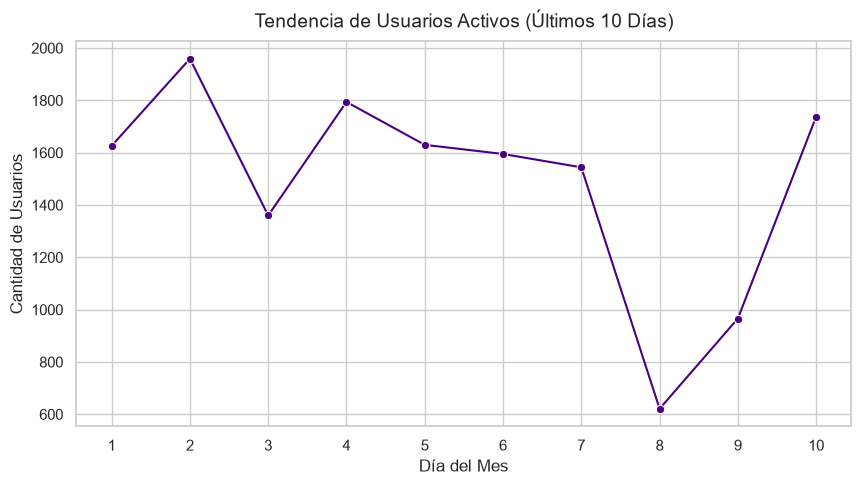

In [2]:
plt.figure(figsize=(10, 5))
# Con solo indicar el nombre de las columnas y el DataFrame, Seaborn hace el resto
sns.lineplot(x='Dia', y='Usuarios_Activos', data=data_app, marker='o', color='indigo')

plt.title('Tendencia de Usuarios Activos (Últimos 10 Días)', fontsize=14, pad=10)
plt.xlabel('Día del Mes')
plt.ylabel('Cantidad de Usuarios')
plt.xticks(dias) # Forzamos a mostrar todos los días en el eje X
plt.show()

## 2. Barplots y Scatterplots (Uso del parámetro `hue`)
La verdadera magia de Seaborn está en el parámetro `hue`. Al asignarle una columna categórica (como 'Plataforma'), Seaborn automáticamente separa los datos por colores y crea una leyenda perfecta sin esfuerzo adicional.

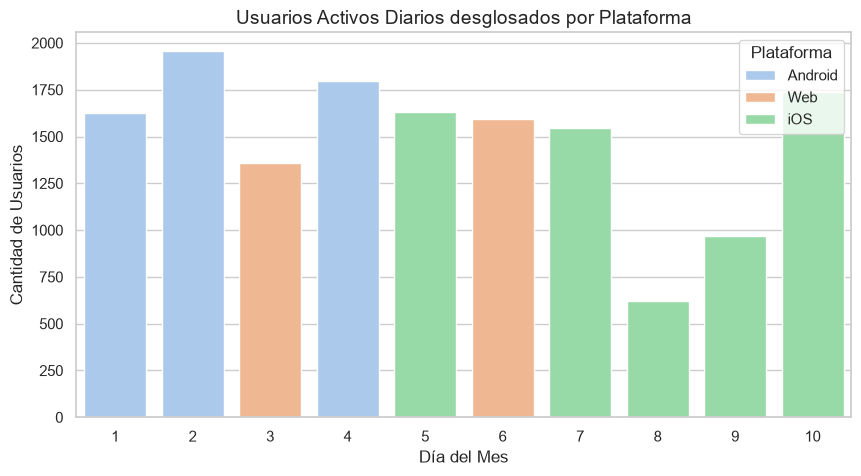

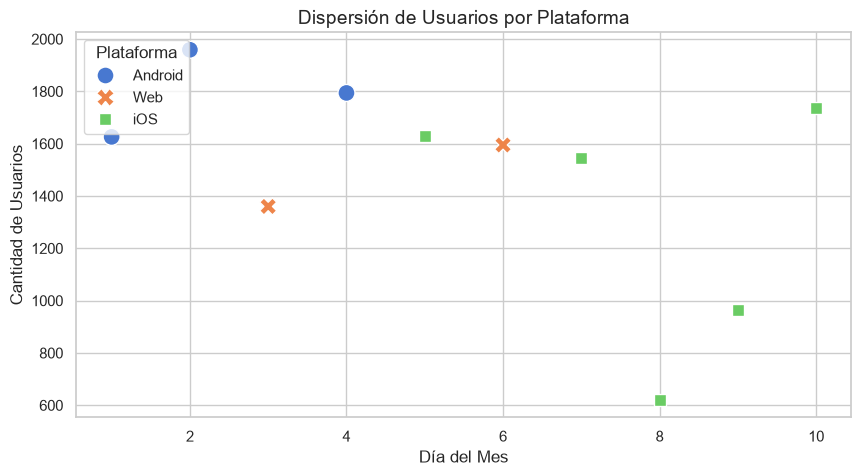

In [3]:
# Crear un Gráfico de Barras agrupado por Plataforma
plt.figure(figsize=(10, 5))
sns.barplot(x='Dia', y='Usuarios_Activos', hue='Plataforma', data=data_app, palette='pastel')
plt.title('Usuarios Activos Diarios desglosados por Plataforma', fontsize=14)
plt.xlabel('Día del Mes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

# Crear un Gráfico de Dispersión (Scatterplot)
plt.figure(figsize=(10, 5))
sns.scatterplot(
    x='Dia', 
    y='Usuarios_Activos', 
    data=data_app, 
    hue='Plataforma', 
    style='Plataforma', # Asigna una forma distinta (círculo, X, cuadrado) a cada categoría
    palette='muted', 
    s=150 # Tamaño de los puntos
)
plt.title('Dispersión de Usuarios por Plataforma', fontsize=14)
plt.xlabel('Día del Mes')
plt.ylabel('Cantidad de Usuarios')
plt.show()